# ChurnSense — Exploratory Data Analysis

## Objective

The objective of this analysis is to understand customer churn patterns in the Telco Customer Churn dataset.

We will investigate:
- Customer churn distribution
- Customer tenure and monthly charges
- Churn rates across categorical features
- Relationships between numerical variables
- Data quality issues that need to be addressed during preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\PARTH\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df["TotalCharges"].dtype

dtype('float64')

In [9]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [10]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [11]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "TotalCharges", "Churn"]]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,NaN,No
753,3115-CZMZD,0,NaN,No
936,5709-LVOEQ,0,NaN,No
1082,4367-NUYAO,0,NaN,No
1340,1371-DWPAZ,0,NaN,No
3331,7644-OMVMY,0,NaN,No
3826,3213-VVOLG,0,NaN,No
4380,2520-SGTTA,0,NaN,No
5218,2923-ARZLG,0,NaN,No
6670,4075-WKNIU,0,NaN,No


In [12]:
df[df["TotalCharges"].isnull()]["tenure"].unique()

array([0])

In [13]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [14]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [15]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [16]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

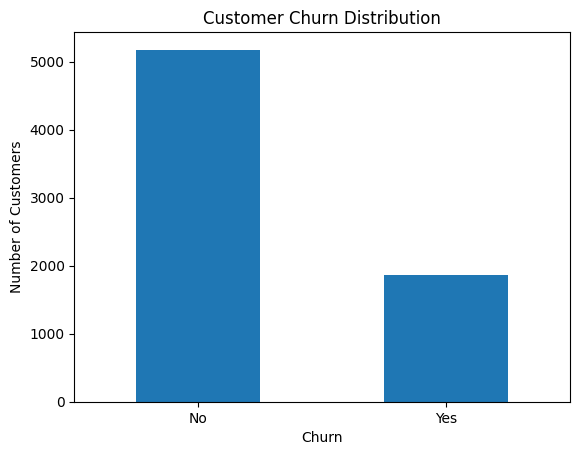

In [18]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

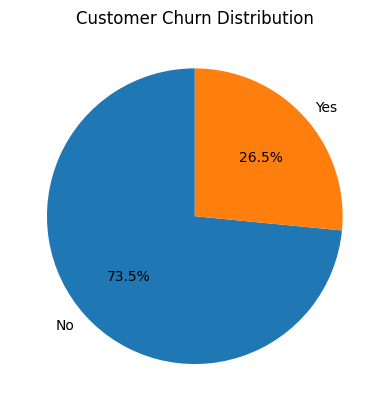

In [19]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

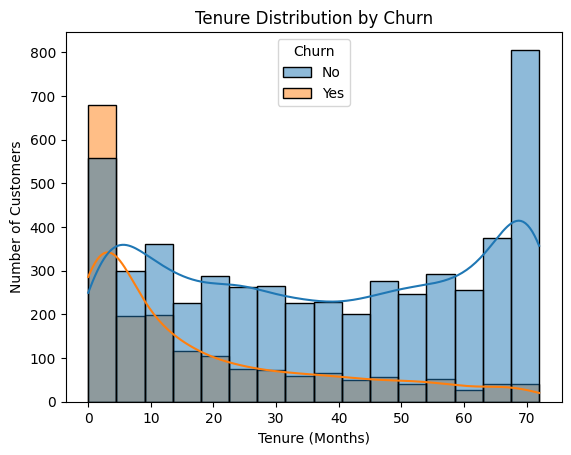

In [30]:
sns.histplot(data=df, x="tenure", hue="Churn", kde=True)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.savefig("../reports/tenure_distribution_by_churn.png", bbox_inches="tight")
plt.show()

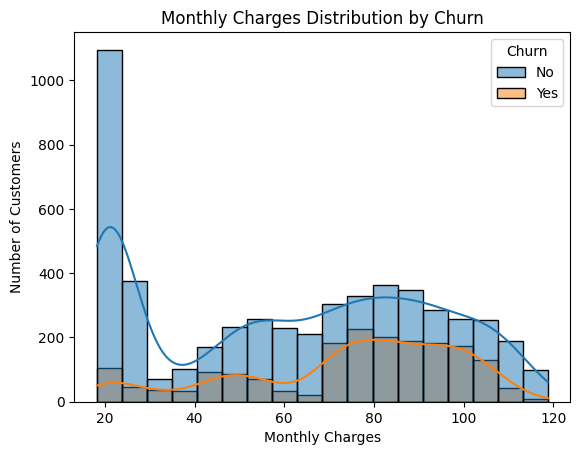

In [31]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.savefig("../reports/monthly_charges_by_churn.png", bbox_inches="tight")
plt.show()

In [23]:
df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

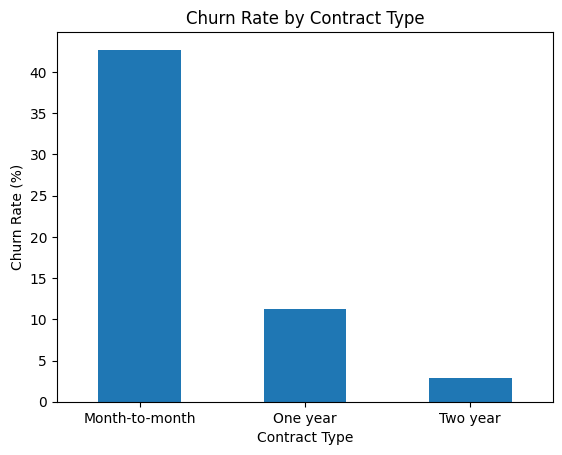

In [29]:
contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.savefig("../reports/churn_rate_by_contract.png", bbox_inches="tight")
plt.show()

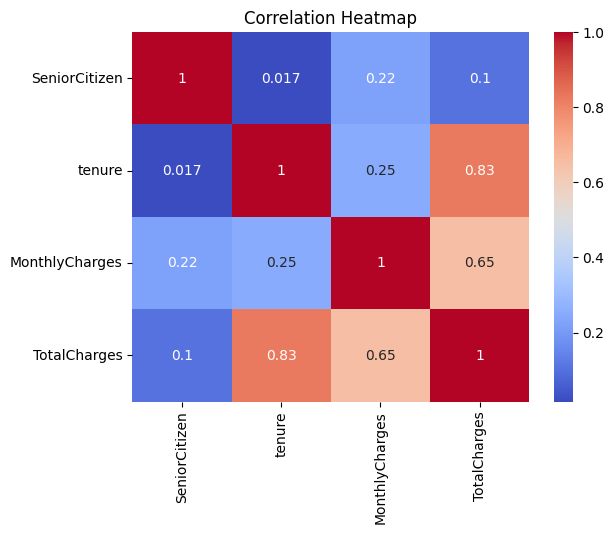

In [32]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("../reports/correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Business Insights

### 1. Contract Type and Churn

Customers on month-to-month contracts have a much higher churn rate (42.71%) compared with customers on one-year (11.27%) and two-year contracts (2.83%). This suggests that customers with longer-term contracts are significantly less likely to churn.

### 2. Overall Customer Churn

Out of 7,043 customers, 1,869 customers have churned, while 5,174 have stayed. This indicates that customer churn represents a significant portion of the customer base and should be an important business concern.

### 3. Customer Tenure and Churn

Customers with shorter tenure show a higher tendency to churn, while customers who have stayed with the company for a longer period are generally less likely to churn. This indicates that the early stage of the customer relationship is important for retention.

### 4. Monthly Charges and Churn

Customers with higher monthly charges show a greater tendency to churn compared with customers paying lower monthly charges. This suggests that pricing and the customer's monthly financial commitment may influence retention.

### 5. Relationships Between Numerical Variables

The correlation heatmap shows the relationships among the numerical variables in the dataset. Tenure and TotalCharges have a strong positive relationship, which is expected because customers who stay longer generally accumulate higher total charges. MonthlyCharges has a weaker relationship with tenure.

## Data Issues for Preprocessing

- `customerID` is an identifier and should be removed before model training.
- `Churn` is a categorical target variable and needs to be converted into a numerical format.
- Categorical features need to be encoded before machine learning.
- Numerical features may require scaling depending on the model.
- `TotalCharges` required conversion from object/text format to numeric format.
- The dataset contains an imbalanced churn target, so stratified splitting and appropriate evaluation metrics should be considered.

In [27]:
import os
os.getcwd()

'e:\\Telecom churn\\notebooks'

In [28]:
import os

os.makedirs("../reports", exist_ok=True)